In [ ]:
# Actividad 5 - Procesamiento de conjuntos de datos en Python
# Integrantes
# 2121619 Yareli Nataly Herrera Milán     N5
# 2111019 Roberto Tadeo Vazquez Rodriguez N5
# 2178074 Esteban Capetillo Martínez      N5
# 2107169 Roberto Ortega Sandoval         N5
# 1911302 Ana Karen Cantú Hinojosa        N5


In [ ]:
#importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Carga de datos
df = pd.read_csv('/content/robot_sensors.csv')

In [ ]:
# Muestra las primeras 3 líneas de datos.
print(df.head(3))

   Tiempo (s)  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
0           0       43.708611          9.256646         23.925585
1           1       95.564288         27.095047         23.704682
2           2       75.879455         43.647292         33.593819
3           3       63.879264         36.611244         23.743193
4           4       24.041678         40.328057         24.079246


In [ ]:
# Obtén información sobre las columnas y el tipo de datos de cada una.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tiempo (s)        1000 non-null   int64  
 1   Distancia (cm)    1000 non-null   float64
 2   Velocidad (cm/s)  1000 non-null   float64
 3   Temperatura (°C)  1000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 31.4 KB
None


In [ ]:
# número que  hay en total en el conjunto de dato
print(df.shape)

(1000, 4)


In [ ]:
# limpieza de datos, verifica si hay datos nulos en alguna columna
print(df.isnull().sum())
# al ejecutar se muestra 30 datos nulos, se deben de eliminar

Tiempo (s)           0
Distancia (cm)      30
Velocidad (cm/s)    30
Temperatura (°C)    30
dtype: int64


In [ ]:
df['Distancia (cm)'] = df['Distancia (cm)'].fillna(df['Distancia (cm)'].mean())
df['Velocidad (cm/s)'] = df['Velocidad (cm/s)'].fillna(df['Velocidad (cm/s)'].mean())
df['Temperatura (°C)'] = df['Temperatura (°C)'].fillna(df['Temperatura (°C)'].mean())

In [ ]:
# verificar si los datos nulos se eliminaron
print(df.isnull().sum())

Tiempo (s)          0
Distancia (cm)      0
Velocidad (cm/s)    0
Temperatura (°C)    0
dtype: int64


In [ ]:
#filtro de valores atipicos
df["Velocidad (cm/s)"].min() # no existe  velocidad negativa

0.16091318

In [ ]:
df["Distancia (cm)"].min()

10.41688207

In [ ]:
df["Temperatura (°C)"].min()

20.00017452

In [ ]:
#Normalizar los datos numéricos con Min-Max Scaling
# explicar que columnas se van a normalizar
columnas = ['Tiempo (s)', 'Distancia (cm)', 'Velocidad (cm/s)', 'Temperatura (°C)']

# Inicializar df_normalizar como una copia de df
df_normalizar = df.copy()

for col in columnas:  # Repite el proceso para cada columna de la lista
    df_normalizar[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

print(df_normalizar.head(10))

   Tiempo (s)  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
0    0.000000        0.371735          0.182609          0.262269
1    0.001001        0.950755          0.540740          0.247509
2    0.002002        0.730954          0.873049          0.908233
3    0.003003        0.596960          0.731791          0.250082
4    0.004004        0.152134          0.806411          0.272535
5    0.005005        0.152110          0.658069          0.761054
6    0.006006        0.053716          0.691690          0.450716
7    0.007007        0.865799          0.849208          0.778404
8    0.008008        0.599429          0.247391          0.065498
9    0.009009        0.706915          0.488064          0.488630


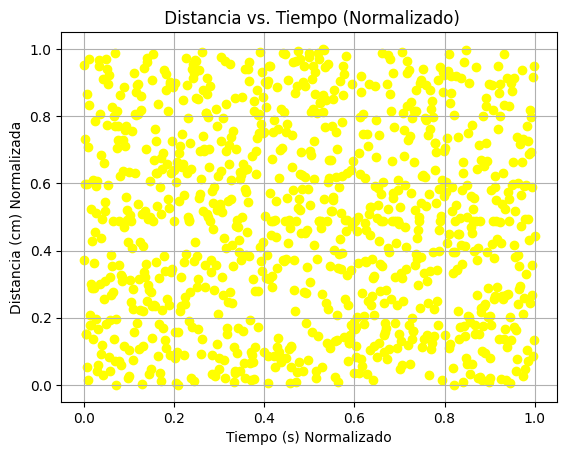

In [ ]:
# GRAFICO DE DISTANCIA vs TIEMPO YA NORMALIZADOS
plt.scatter(df_normalizar["Tiempo (s)"], df_normalizar["Distancia (cm)"], color='yellow')
plt.title(' Distancia vs. Tiempo (Normalizado)')
plt.xlabel('Tiempo (s) Normalizado')
plt.ylabel('Distancia (cm) Normalizada')
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

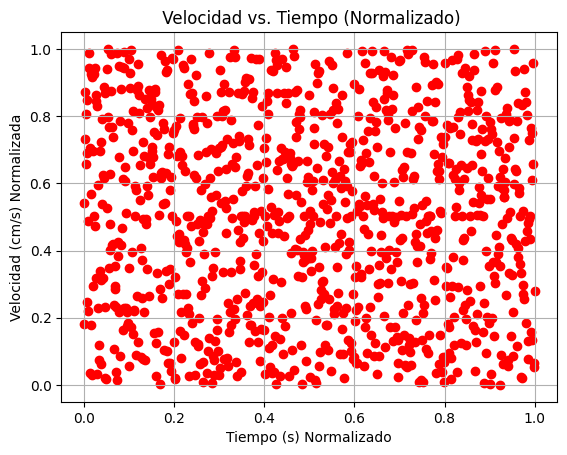

In [ ]:
# GRAFICO DE VELOCIDAD vs TIEMPO YA NORMALIZADOS
plt.scatter(df_normalizar["Tiempo (s)"], df_normalizar["Velocidad (cm/s)"], color='red')
plt.title(' Velocidad vs. Tiempo (Normalizado)')
plt.xlabel('Tiempo (s) Normalizado')
plt.ylabel('Velocidad (cm/s) Normalizada')
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico

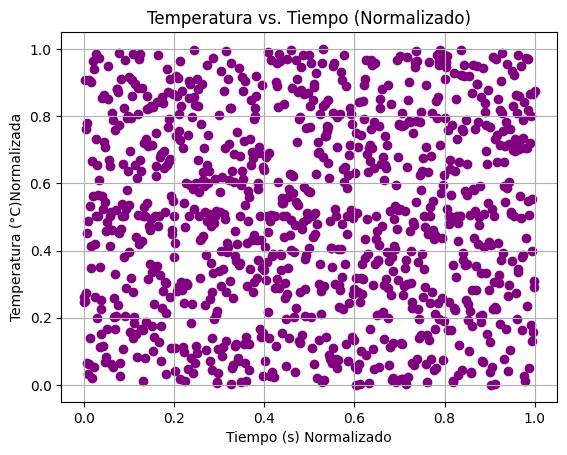

In [ ]:
# GRAFICO DE TEMPERATURA vs TIEMPO YA NORMALIZADOS
plt.scatter(df_normalizar["Tiempo (s)"], df_normalizar["Temperatura (°C)"], color='purple')
plt.title('Temperatura vs. Tiempo (Normalizado)')
plt.xlabel('Tiempo (s) Normalizado')
plt.ylabel('Temperatura (°C)Normalizada')
plt.grid(True)  # Muestra la cuadrícula
plt.show()  # Muestra el gráfico